# Feature Correlations Notebook
This notebook is to check the correlations of the model features as well as to check the cross-correlations of the feautures across datasets

### Load the libraries needed

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load the datasets

In [6]:
industry_df = pd.read_csv("data/potential_model_features/percents_sa/industry_level_totals_exp.csv")
national_df = pd.read_csv("data/potential_model_features/percents_sa/national_level_totals_exp.csv")
regional_df = pd.read_csv("data/potential_model_features/percents_sa/regional_level_totals_exp.csv")
state_df = pd.read_csv("data/potential_model_features/percents_sa/state_level_totals_exp.csv")

## Plot the correlation matrices of the datasets against themselves

In [9]:
import re

def shorten_names(df):
    df = df.copy()  # Avoid modifying original DataFrame
    df.columns = [re.split(r'\s*-\s*', col)[0] for col in df.columns]
    return df

### Industry Correlations

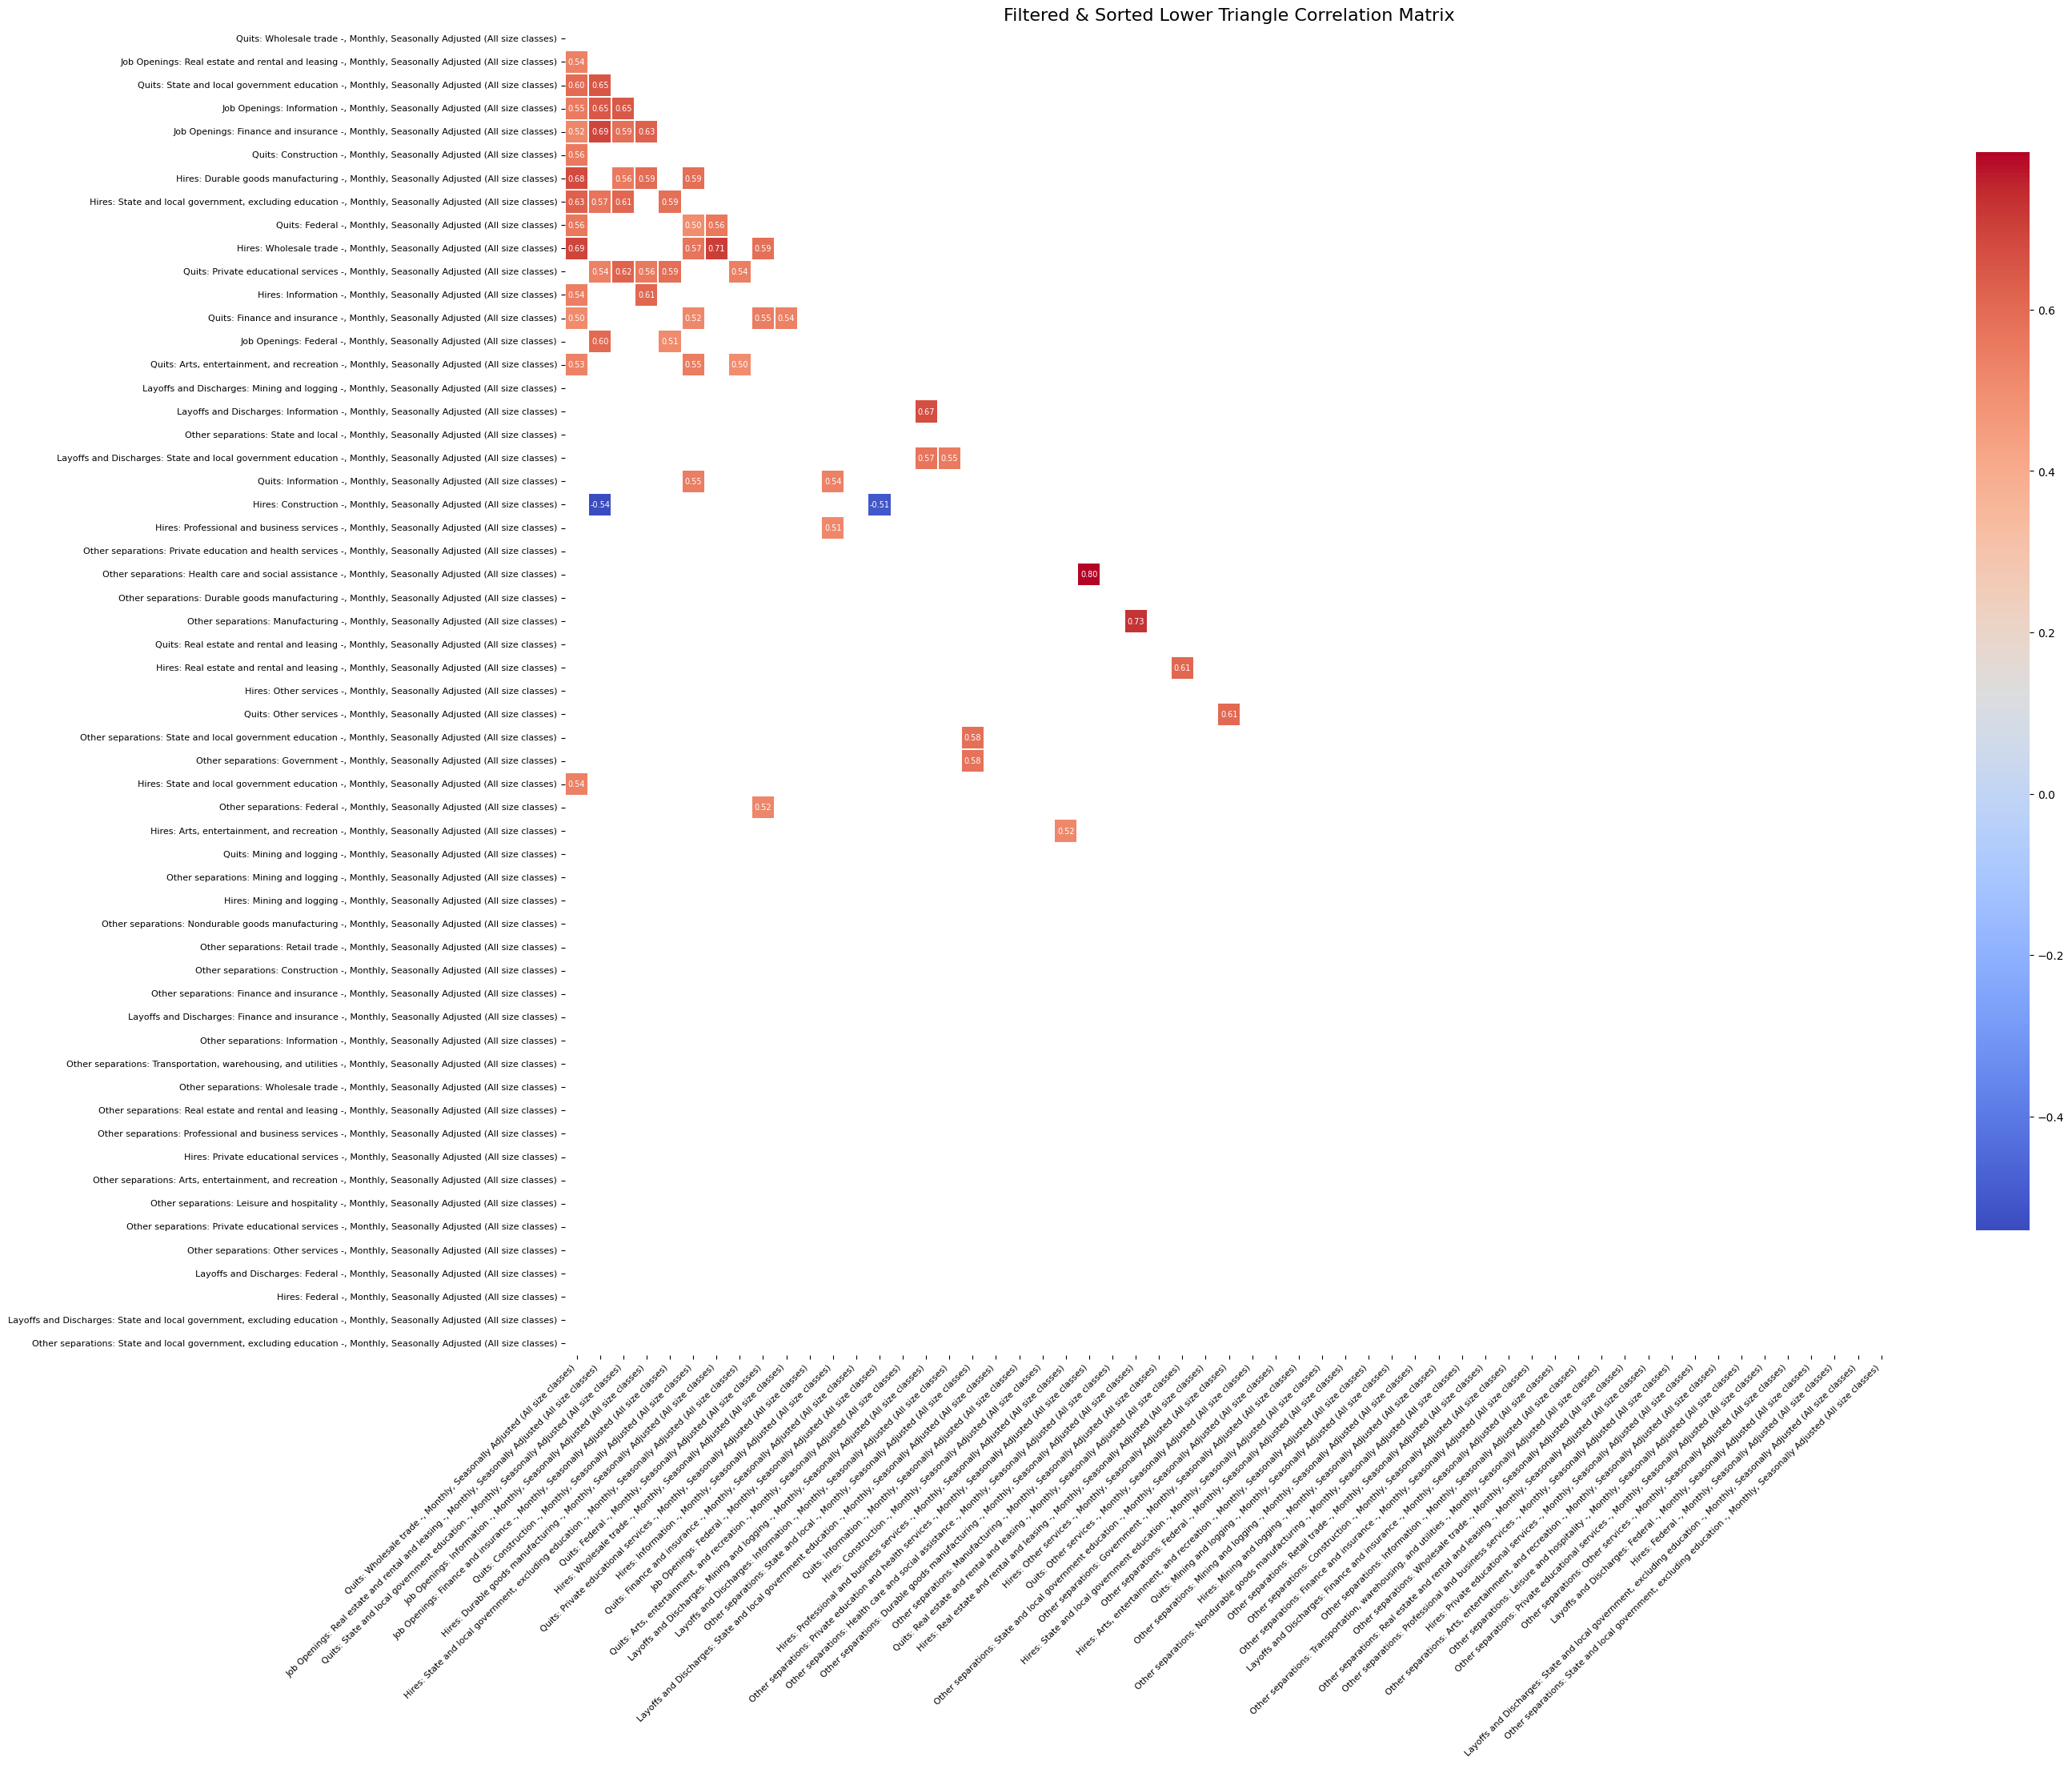

In [14]:
# Step 1: Compute correlation matrix
corr = industry_df.corr()

# Step 2: Filter weak correlations (absolute value < 0.3)
filtered_corr = corr.where(np.abs(corr) >= 0.5)

# Step 3: Sort features by total correlation strength
strength = filtered_corr.abs().sum().sort_values(ascending=False)
sorted_corr = filtered_corr.loc[strength.index, strength.index]

# Step 4: Mask upper triangle
mask = np.triu(np.ones_like(sorted_corr, dtype=bool))

# Step 5: Plot heatmap with readability enhancements
plt.figure(figsize=(28, 24))
sns.heatmap(
    sorted_corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 7}
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Filtered & Sorted Lower Triangle Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### Grab all the important correlations and put them into a different industry_df

In [20]:
# Step 1: Compute absolute correlation matrix
corr_matrix = industry_df.corr().abs()

# Step 2: Set threshold for strong correlation
threshold = 0.5

# Step 3: Identify features with at least one strong correlation (excluding self-correlation)
strong_corr_mask = (corr_matrix > threshold) & (np.eye(len(corr_matrix)) == 0)
features_to_keep = strong_corr_mask.any(axis=1)

# Step 4: Filter original DataFrame to keep only those features
industry_df_strong = industry_df.loc[:, features_to_keep]

# Optional: print resulting feature names
print("Retained features with strong correlations:")
print(industry_df_strong.columns.tolist())
print(len(industry_df_strong.columns))

industry_df_strong.head()

Retained features with strong correlations:
['Layoffs and Discharges: Mining and logging -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Construction -, Monthly, Seasonally Adjusted (All size classes)', 'Quits: Construction -, Monthly, Seasonally Adjusted (All size classes)', 'Other separations: Manufacturing -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)', 'Other separations: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)', 'Quits: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Information -, Monthly, Seasonally Adjusted (All size classes)', 'Job Openings: Information -, Monthly, Seasonally Adjusted (All size classes)', 'Layoffs and Discharges: Information -, Monthly, Seasonally Adjusted (All size classes)', 'Quits: Information -, Monthly, Seas

,"Layoffs and Discharges: Mining and logging -, Monthly, Seasonally Adjusted (All size classes)","Hires: Construction -, Monthly, Seasonally Adjusted (All size classes)","Quits: Construction -, Monthly, Seasonally Adjusted (All size classes)","Other separations: Manufacturing -, Monthly, Seasonally Adjusted (All size classes)","Hires: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)","Other separations: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)","Hires: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)","Quits: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)","Hires: Information -, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Information -, Monthly, Seasonally Adjusted (All size classes)",...,"Other separations: Government -, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Federal -, Monthly, Seasonally Adjusted (All size classes)","Other separations: Federal -, Monthly, Seasonally Adjusted (All size classes)","Quits: Federal -, Monthly, Seasonally Adjusted (All size classes)","Other separations: State and local -, Monthly, Seasonally Adjusted (All size classes)","Hires: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Other separations: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Quits: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education -, Monthly, Seasonally Adjusted (All size classes)"
0,2.0,6.1,1.6,0.3,2.5,0.3,2.7,1.1,3.0,4.2,...,0.2,2.4,0.3,0.6,0.2,1.6,0.5,0.2,0.6,1.8
1,1.6,7.2,2.4,0.2,2.6,0.3,2.5,1.7,4.6,4.3,...,0.2,2.4,0.3,0.7,0.2,1.5,0.4,0.2,0.7,1.8
2,0.9,7.1,2.6,0.2,2.5,0.2,2.8,1.6,3.6,3.8,...,0.2,2.2,0.3,0.6,0.2,1.8,0.5,0.2,0.6,1.9
3,1.4,8.4,2.9,0.3,2.4,0.3,2.5,1.6,3.0,3.4,...,0.2,2.1,0.2,0.7,0.2,1.6,0.4,0.2,0.7,1.8
4,1.3,6.7,2.9,0.3,2.3,0.3,2.7,1.5,3.4,4.4,...,0.3,2.3,0.3,0.6,0.2,1.6,0.3,0.2,0.5,1.7


### Plot the correlation matrix of the strong dataframe

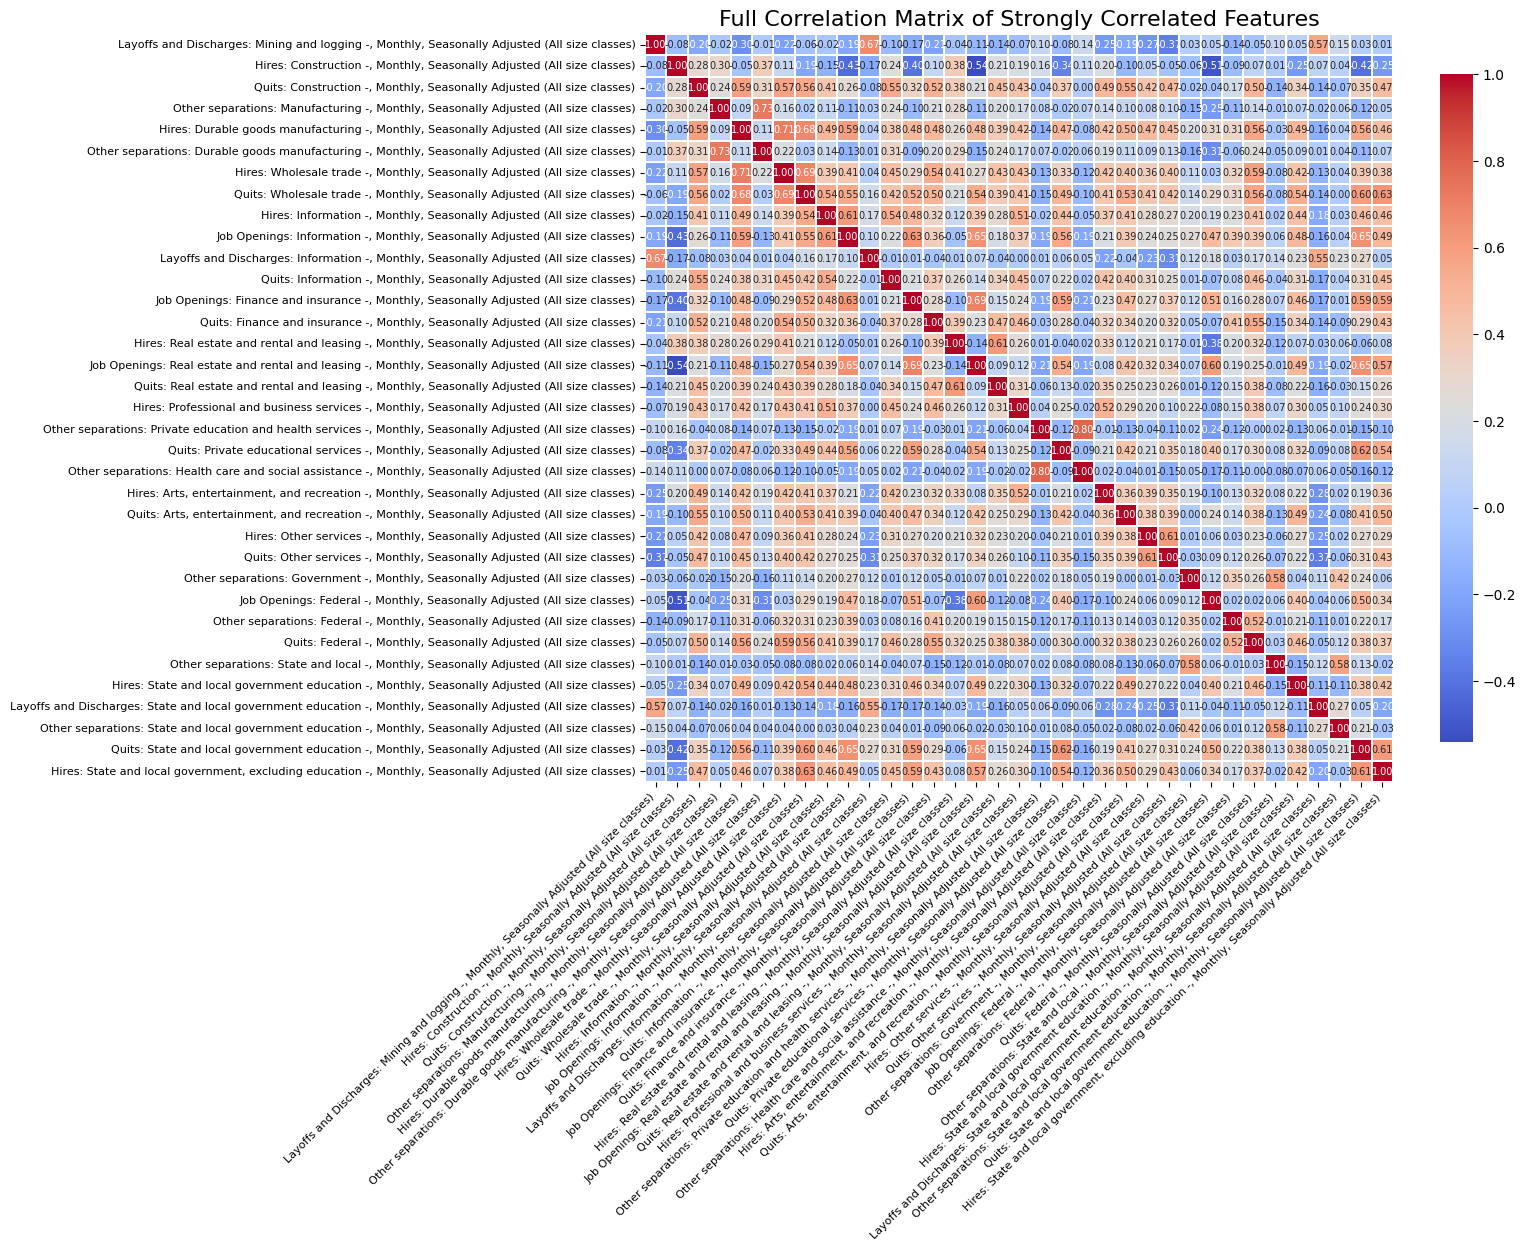

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute full correlation matrix
corr_matrix = industry_df_strong.corr()

# Step 2: Set up the plot
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 7}
)

# Step 3: Improve label readability
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Full Correlation Matrix of Strongly Correlated Features', fontsize=16)
plt.tight_layout()
plt.show()